# L02 · Data Visualization using ggplot2 (seaborn version)

*Companion notebook to **Section 1.2 (Lecture 2)** of the LaTeX notes (`latex/main.pdf`). Run the cells top to bottom.*

In [1]:
# --- Setup: imports, fixed seed, and a relative path to the data/ folder ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

rng = np.random.default_rng(2024)          # fixed seed for reproducibility
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid")

# Find the project's data/ folder by walking up from the notebook's folder.
DATA = next(p / "data" for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
print("data folder:", DATA)

data folder: /home/claude/LSM/data


## Theory recap
`ggplot(data) + geom(mapping = aes(...))`: an **aesthetic** (colour, shape, size) is a visual channel. **Mapping** a variable to it and **scaling** assigns one level of the aesthetic to each level of the variable, with a legend. **Facets** split the plot into panels by one (`facet_wrap`) or two (`facet_grid`) variables. Viridis palettes are perceptually uniform and colour-blind safe.

In seaborn: `hue=` plays the role of `colour=`, `palette="viridis"` the role of `scale_colour_viridis_d()`, and `col=`/`row=` in `relplot` the role of facets.

In [2]:
mpg = pd.read_csv(DATA / "mpg.csv")
print(mpg.shape)
mpg.head()

(234, 11)


,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


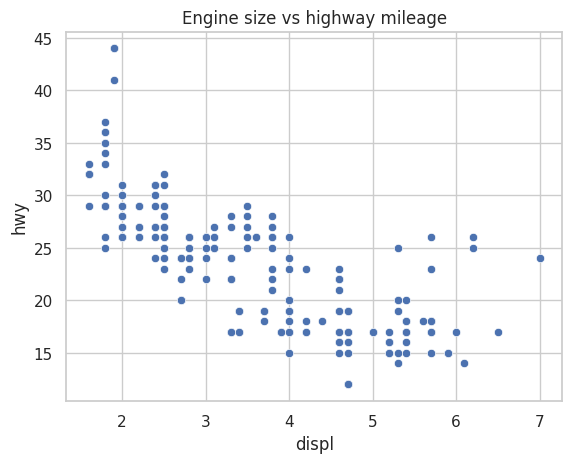

correlation: -0.766


In [3]:
# ggplot(data=mpg) + geom_point(mapping=aes(x=displ, y=hwy))
ax = sns.scatterplot(data=mpg, x="displ", y="hwy")
ax.set_title("Engine size vs highway mileage"); plt.show()
print("correlation:", mpg.displ.corr(mpg.hwy).round(3))   # negative relationship

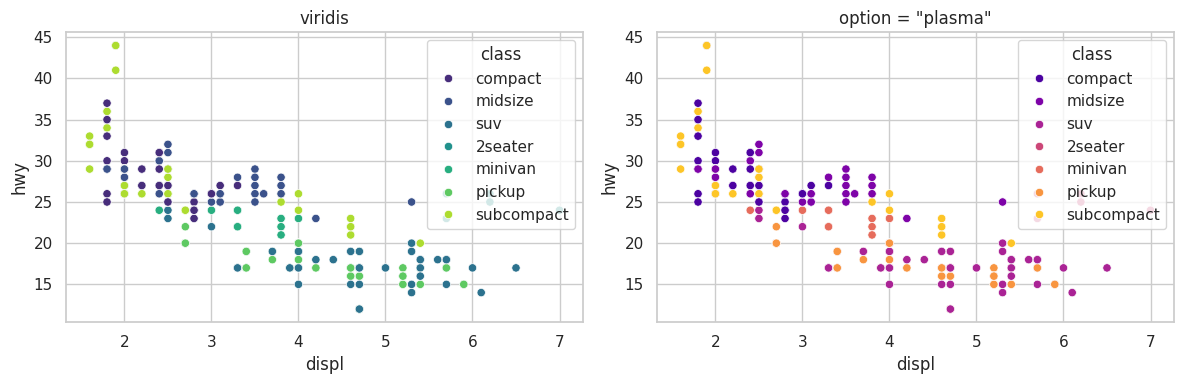

In [4]:
# aes(colour = class) + scale_colour_viridis_d()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=mpg, x="displ", y="hwy", hue="class", palette="viridis", ax=ax[0]).set_title("viridis")
sns.scatterplot(data=mpg, x="displ", y="hwy", hue="class", palette="plasma", ax=ax[1]).set_title('option = "plasma"')
plt.tight_layout(); plt.show()

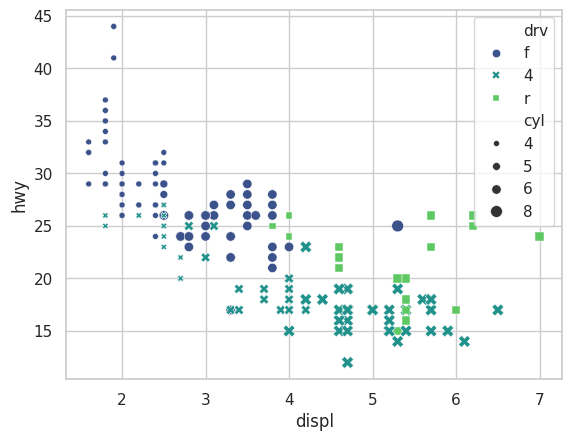

In [5]:
# Other aesthetics: shape and size
sns.scatterplot(data=mpg, x="displ", y="hwy", style="drv", size="cyl", hue="drv", palette="viridis")
plt.show()

In [6]:
# The 2-seaters: big engines, unusually good mileage
mpg[(mpg.displ > 5) & (mpg.hwy > 22)][["manufacturer", "model", "displ", "hwy", "class"]]

,manufacturer,model,displ,hwy,class
23,chevrolet,corvette,5.7,26,2seater
24,chevrolet,corvette,5.7,23,2seater
25,chevrolet,corvette,6.2,26,2seater
26,chevrolet,corvette,6.2,25,2seater
27,chevrolet,corvette,7.0,24,2seater
158,pontiac,grand prix,5.3,25,midsize


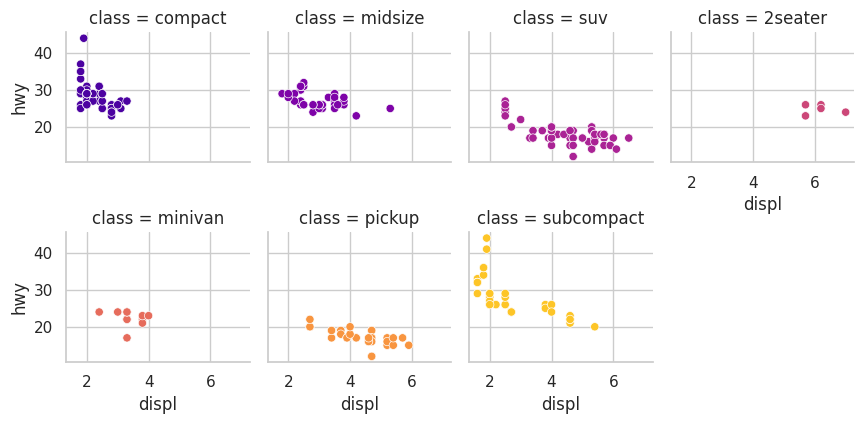

In [7]:
# facet_wrap(~ class, nrow = 2)
g = sns.relplot(data=mpg, x="displ", y="hwy", col="class", col_wrap=4, height=2.2, hue="class", palette="plasma", legend=False)
plt.show()

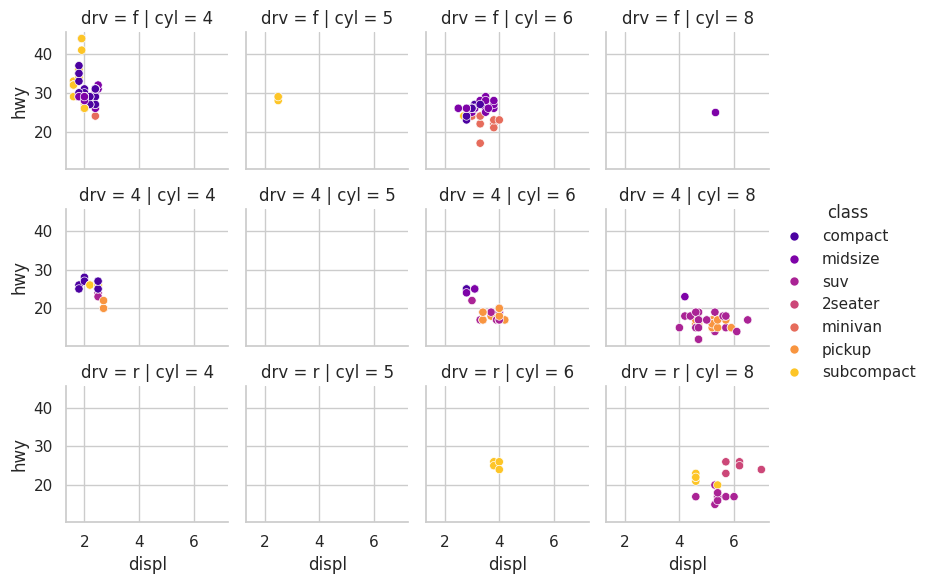

cyl,4,5,6,8
drv,,,,
4,23,0,32,48
f,58,4,43,1
r,0,0,4,21


In [8]:
# facet_grid(drv ~ cyl)
g = sns.relplot(data=mpg, x="displ", y="hwy", row="drv", col="cyl", height=2, hue="class", palette="plasma")
plt.show()
pd.crosstab(mpg.drv, mpg.cyl)     # zeros = empty panels

## Try it yourself
1. Map the *continuous* variable `cty` to colour (`hue="cty"`). How does the legend change? (Exercise 2.)
2. Count the levels of `class`, `drv`, `cyl` with `mpg.nunique()`. How many facet_grid panels are there? (Exercise 4.)
3. Put `colour="blue"` *outside* the mapping: `sns.scatterplot(..., color="blue")`.